In [26]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

from neuron import h
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import seaborn as sns

import glob
import re
import csv

project = "temporal-interference"

# In-vivo inputs

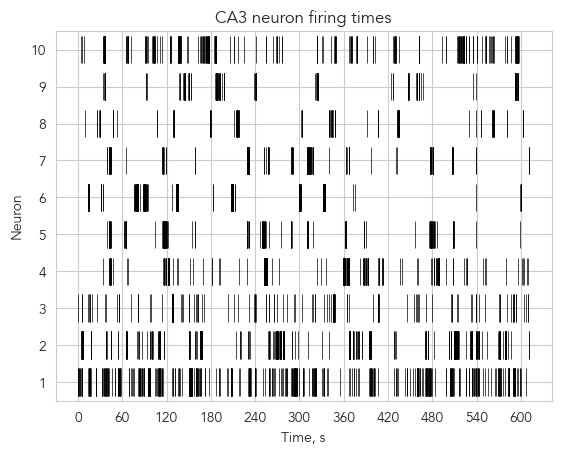

In [2]:
for i, file in enumerate(glob.glob("CA3-INVIVO-STIM/*.txt")):
    data = pd.read_csv(file, header = None)
    data.columns = ["Time"]
    data.Time = data.Time / 1000
    plt.eventplot(data.Time, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

plt.ylim(0.5, 10.5)
plt.ylabel("Neuron")
plt.yticks(np.arange(1, 11, 1))

plt.xlabel("Time, s")
plt.xticks(np.arange(0, 660, 60))

plt.title("CA3 neuron firing times")
plt.show()

**Figure.** CA3 neuron firing times, recorded *in-vivo*.

In [3]:
stimuli = []

for i, file in enumerate(glob.glob("CA3-INVIVO-STIM/*.txt")):
    data = pd.read_csv(file, header = None)
    data.columns = [f"{i}"]
    data = data.sort_values(by = f"{i}")
    
    stimuli.append(data)

stimuli = pd.concat(stimuli, axis = 1)

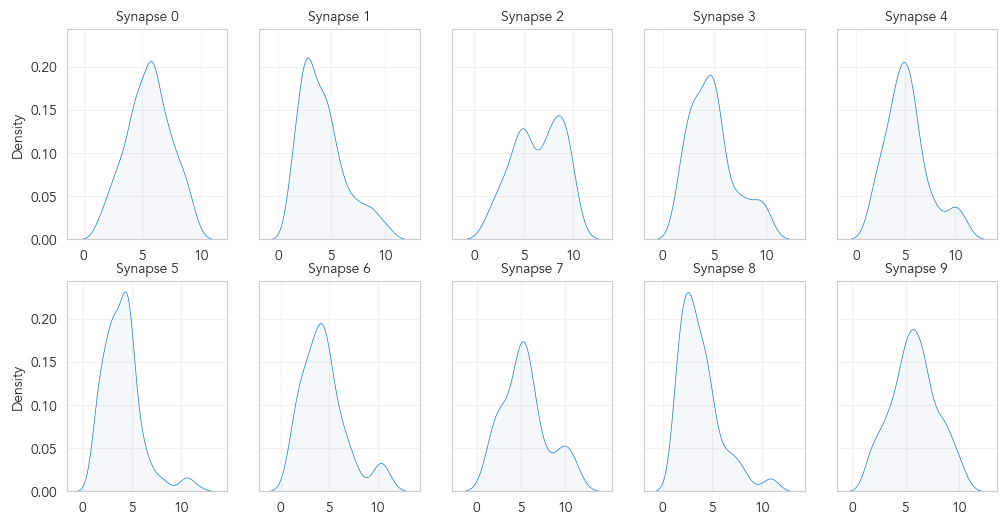

In [4]:
fig, axs = plt.subplots(nrows = 2, ncols = 5, figsize = (12, 6), sharey = True)
axs = axs.flatten()

for i in stimuli:
    stim = stimuli[i].dropna().tolist()
    isi = np.log(np.diff(stim))
    ax = axs[int(i)]

    sns.kdeplot(
        isi,
        bw_adjust = 1,
        ax = ax,
        fill = True,
        alpha = 0.05,
        linewidth = 0.5
    )
    
    ax.set_xticks([0, 5, 10])
    ax.grid(alpha = 0.25)
    
    ax.set_title(f"Synapse {i}", fontsize = 10)

**Figure**. Interspike interval distributions for *in-vivo* inputs in all synapses.

## *In-vivo* synaptic stimulation without temporal interference 

In [5]:
id = 0
ti = "1000_130_0.9"
prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti}_0.1"

In [6]:
voltage = pd.read_csv(f"{prefix}/voltage.csv", index_col = 0)

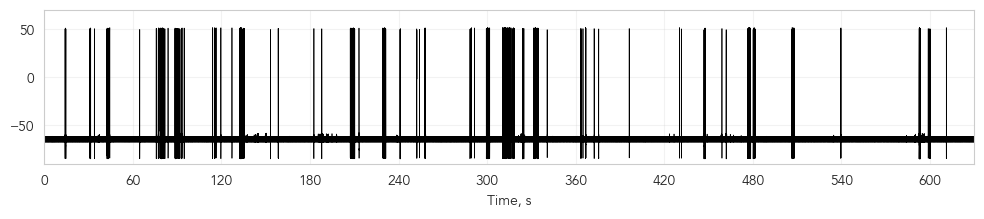

In [7]:
plt.figure(figsize = (12, 2))

plt.plot(
    voltage.Time / 1000,
    voltage.Voltage,
    linewidth = 0.5,
    color = "black"
)

plt.grid(alpha = 0.25)
plt.xlim(0, 630)
plt.xticks(np.arange(0, 630, 60))
plt.xlabel("Time, s")
plt.ylim(-90, 70)

plt.show()

In [8]:
ti = "noTI"
prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti}_0.1"
weights = pd.read_csv(f"{prefix}/synapse_weights.csv", index_col = 0)

time = weights.Time / 1000
weights.drop("Time", axis = 1, inplace = True)
mean_weights = weights.mean(axis = 1)

In [9]:
ti = "1000_130_0.9"
prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti}_0.1"
weights_130 = pd.read_csv(f"{prefix}/synapse_weights.csv", index_col = 0)

time_130 = weights_130.Time / 1000
weights_130.drop("Time", axis = 1, inplace = True)
mean_weights_130 = weights_130.mean(axis = 1)

In [10]:
ti = "1000_5_0.9"
prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti}_0.1"
weights_5 = pd.read_csv(f"{prefix}/synapse_weights.csv", index_col = 0)

time_5 = weights_5.Time / 1000
weights_5.drop("Time", axis = 1, inplace = True)
mean_weights_5 = weights_5.mean(axis = 1)

In [11]:
ti = "1000_0_0.32"
prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti}_0.1"
weights_0 = pd.read_csv(f"{prefix}/synapse_weights.csv", index_col = 0)

time_0 = weights_0.Time / 1000
weights_0.drop("Time", axis = 1, inplace = True)
mean_weights_0 = weights_0.mean(axis = 1)

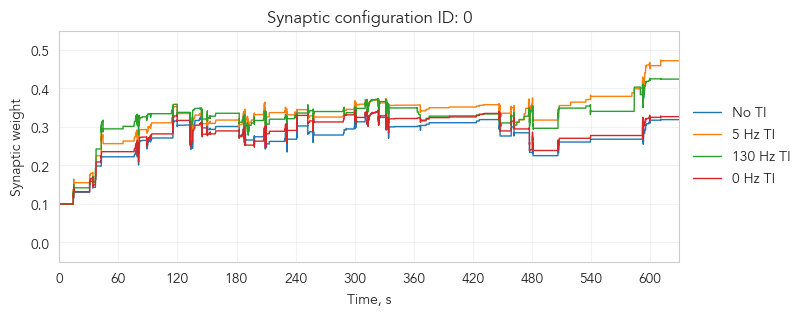

In [12]:
plt.figure(figsize = (8, 3))

plt.plot(
    time,
    mean_weights,
    linewidth = 1,
    label = "No TI",
    color = "tab:blue"
)

plt.plot(
    time_5,
    mean_weights_5,
    linewidth = 1,
    label = "5 Hz TI",
    color = "tab:orange"
)

plt.plot(
    time_130,
    mean_weights_130,
    linewidth = 1,
    label = "130 Hz TI",
    color = "tab:green"
)

plt.plot(
    time_0,
    mean_weights_0,
    linewidth = 1,
    label = "0 Hz TI",
    color = "tab:red"
)

plt.grid(alpha = 0.25)
plt.xlim(0, 630)
plt.xticks(np.arange(0, 630, 60))
plt.xlabel("Time, s")
plt.ylim(-0.05, 0.55)
plt.ylabel("Synaptic weight")
plt.legend(
    loc = "center right",
    frameon = False,
    ncol = 1,
    bbox_to_anchor = (1.2, 0.5)
)

plt.title(f"Synaptic configuration ID: {id}")
plt.show()

**Figure.** Synaptic weight dynamics with _in-vivo_ synaptic inputs.

In [13]:
ti = "noTI"
prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti}_0.1"
synapse_voltage = pd.read_csv(f"{prefix}/synapse_voltage.csv", index_col = 0)

In [20]:
ti = "1000_130_0.9"
prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti}_0.1"
synapse_voltage_130 = pd.read_csv(f"{prefix}/synapse_voltage.csv", index_col = 0)

In [21]:
ti = "1000_5_0.9"
prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti}_0.1"
synapse_voltage_5 = pd.read_csv(f"{prefix}/synapse_voltage.csv", index_col = 0)

In [22]:
ti = "1000_0_0.32"
prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti}_0.1"
synapse_voltage_0 = pd.read_csv(f"{prefix}/synapse_voltage.csv", index_col = 0)

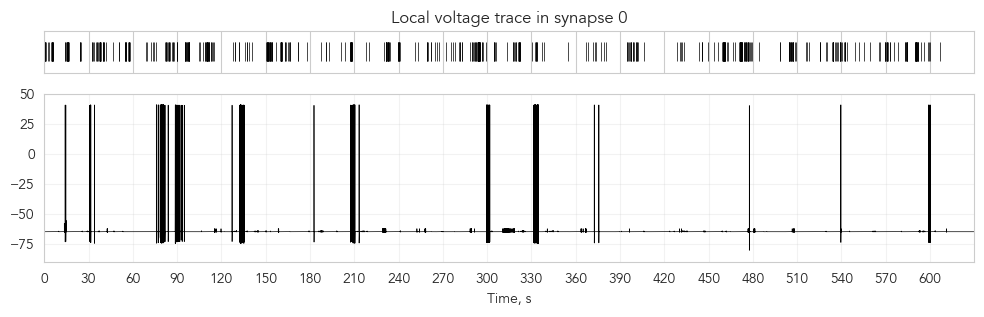

In [14]:
synapse_idx = "0"

synapse = f"Synapse{synapse_idx}"
synapse_stimuli = (stimuli[synapse_idx].dropna() / 1000).tolist()

fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (12, 3), height_ratios = [0.2, 0.8], sharex = True)

ax = axs[0]
ax.eventplot(synapse_stimuli, lineoffsets = 0, linelengths = 0.75, colors = "black", linewidths = 0.5)
ax.set_yticks([])

ax.set_title(f"Local voltage trace in synapse {synapse_idx}")

ax = axs[1]

ax.plot(
    synapse_voltage.Time / 1000,
    synapse_voltage["Synapse0"],
    linewidth = 0.5,
    color = "black"
)

ax.grid(alpha = 0.25)
ax.set_xlim(0, 630)
ax.set_xticks(np.arange(0, 630, 30))
ax.set_xlabel("Time, s")
# ax.set_ylim(-65.5, -64.5)

ax.set_ylim(-90, 50)
# ax.set_xlim(1, 5)

plt.show()

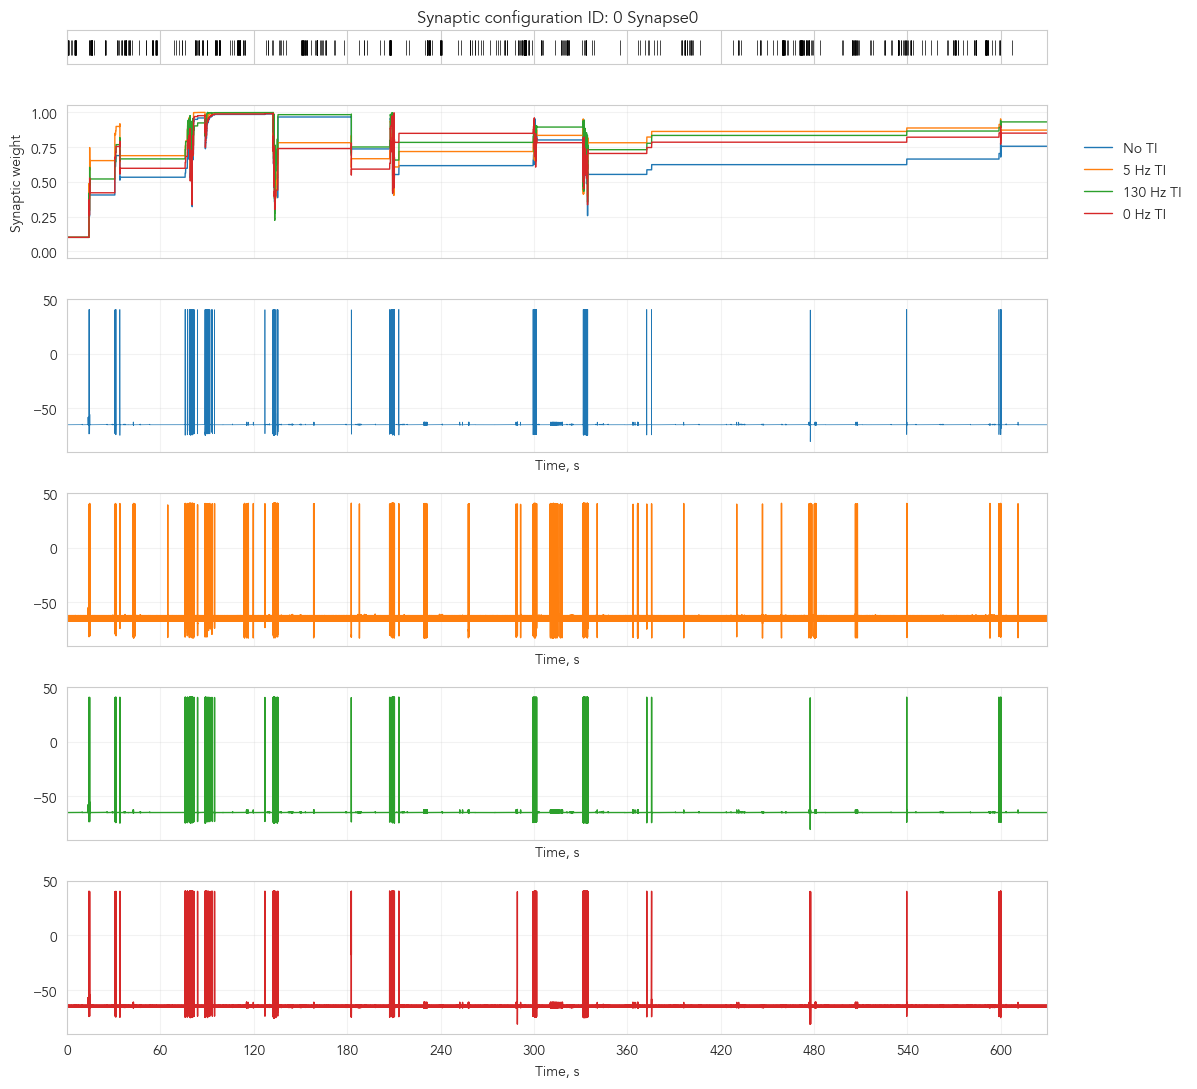

In [25]:
synapse_idx = "0"

synapse = f"Synapse{synapse_idx}"
synapse_stimuli = (stimuli[synapse_idx].dropna() / 1000).tolist()

synapse_weights_no_ti = weights[synapse]
synapse_weights_5 = weights_5[synapse]
synapse_weights_130 = weights_130[synapse]
synapse_weights_0 = weights_0[synapse]

voltage_no_ti = synapse_voltage[synapse]
voltage_130 = synapse_voltage[synapse]
voltage_5 = synapse_voltage_5[synapse]
voltage_0 = synapse_voltage_0[synapse]

fig, axs = plt.subplots(nrows = 6, ncols = 1, figsize = (12, 11), height_ratios = [0.1, 0.45, 0.45, 0.45, 0.45, 0.45], sharex = True)

### Synaptic input

ax = axs[0]

ax.eventplot(synapse_stimuli, lineoffsets = 0, linelengths = 0.75, colors = "black", linewidths = 0.5)
ax.set_yticks([])
ax.set_xlim(0, 630)
ax.set_xticks(np.arange(0, 630, 60))

### Synaptic weights

ax = axs[1]

ax.plot(
    time,
    synapse_weights_no_ti,
    linewidth = 1,
    label = "No TI",
    color = "tab:blue"
)

ax.plot(
    time_5,
    synapse_weights_5,
    linewidth = 1,
    label = "5 Hz TI",
    color = "tab:orange"
)

ax.plot(
    time_130,
    synapse_weights_130,
    linewidth = 1,
    label = "130 Hz TI",
    color = "tab:green"
)

ax.plot(
    time_0,
    synapse_weights_0,
    linewidth = 1,
    label = "0 Hz TI",
    color = "tab:red"
)

ax.grid(alpha = 0.25)
ax.set_xlim(0, 630)
ax.set_xticks(np.arange(0, 630, 60))
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("Synaptic weight")
ax.legend(
    loc = "center right",
    frameon = False,
    ncol = 1,
    bbox_to_anchor = (1.15, 0.5)
)

### Dendritic voltage

ax = axs[2]

ax.plot(
    synapse_voltage.Time / 1000,
    voltage_no_ti,
    linewidth = 0.5,
    color = "tab:blue"
)

ax.grid(alpha = 0.25)
ax.set_xlim(0, 630)
ax.set_xticks(np.arange(0, 630, 60))
ax.set_ylim(-90, 50)
ax.set_yticks([-75, -50, -25, 0, 25])
ax.set_ylabel("Voltage, mV")

ax = axs[3]

ax.plot(
    time_5,
    voltage_5,
    linewidth = 1,
    label = "5 Hz TI",
    color = "tab:orange"
)

ax.grid(alpha = 0.25)
ax.set_xlim(0, 630)
ax.set_xticks(np.arange(0, 630, 60))
ax.set_ylim(-90, 50)
ax.set_yticks([-75, -50, -25, 0, 25])
ax.set_ylabel("Voltage, mV")

ax = axs[4]

ax.plot(
    time_130,
    voltage_130,
    linewidth = 1,
    label = "130 Hz TI",
    color = "tab:green"
)

ax.grid(alpha = 0.25)
ax.set_xlim(0, 630)
ax.set_xticks(np.arange(0, 630, 60))
ax.set_ylim(-90, 50)
ax.set_yticks([-75, -50, -25, 0, 25])
ax.set_ylabel("Voltage, mV")

ax = axs[5]

ax.plot(
    time_0,
    voltage_0,
    linewidth = 1,
    label = "0 Hz TI",
    color = "tab:red"
)

ax.grid(alpha = 0.25)
ax.set_xlim(0, 630)
ax.set_xticks(np.arange(0, 630, 60))
ax.set_xlabel("Time, s")
ax.set_ylim(-90, 50)
ax.set_yticks([-75, -50, -25, 0, 25])
ax.set_ylabel("Voltage, mV")

axs[0].set_title(f"Synaptic configuration ID: {id}, {synapse}")

plt.tight_layout()
plt.savefig("weights.png", dpi = 500, bbox_inches = "tight")
plt.show()

## Final weight distribution (for a single configuration)

In [49]:
def read_final_weights(ti_type, id = "0"):
    prefix = f"output/temporal-interference-1/{id}/in-vivo/{ti_type}_0.1"
    file = f"{prefix}/synapse_weights.csv"
    
    with open(file, "rb") as f:
        f.seek(-2, 2)
        while f.read(1) != b"\n":
            f.seek(-2, 1)
        last_row = f.readline().decode().strip().split(",")

    return [float(x) for x in last_row[2:]]

In [50]:
final = read_final_weights(ti_type = "noTI")
final_5 = read_final_weights(ti_type = "1000_5_0.9")
final_130 = read_final_weights(ti_type = "1000_130_0.9")
final_0 = read_final_weights(ti_type = "1000_0_0.32")

In [90]:
final_weights = pd.DataFrame({
    "Synapse": [f"Synapse{i}" for i in np.arange(0, 10)],
    "No TI": final,
    "5 Hz TI": final_5,
    "130 Hz TI": final_130,
    "0 Hz TI": final_0
})

final_weights = final_weights.melt(
    id_vars = "Synapse",
    value_vars = ["No TI", "5 Hz TI", "130 Hz TI", "0 Hz TI"],
    var_name = "TI",
    value_name = "Weight"
)

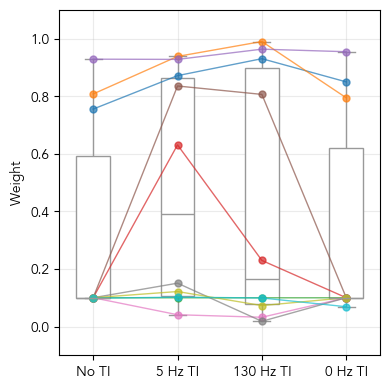

In [91]:
plt.figure(figsize = (4, 4))

order = ["No TI", "5 Hz TI", "130 Hz TI", "0 Hz TI"]

sns.boxplot(
    data = final_weights,
    x = "TI",
    y = "Weight",
    order = order,
    showfliers = False,
    width = 0.4,
    color = "white"
)

for synapse, sub in final_weights.groupby("Synapse"):
    sub = sub.set_index("TI").reindex(order)
    y = sub["Weight"].astype(float).values
    plt.plot(order, y, alpha = 0.7, linewidth = 1, marker = "o", markersize = 5)

plt.ylim(-0.1, 1.1)
plt.xlim(-0.4, 3.4)
plt.grid(alpha = 0.25)
plt.xlabel("")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

TODO:
- Run simulations for more synaptic configurations

+ Create figures of synaptic weight dynamics for each synaptic configuration (such as the one above)
+ Plot weight dynamics of individual synapses + dendritic voltage traces of individual synapses
+ Boxplot of final weight distributions - connecting the points of individual synapses
- Plot somatic voltage traces as well

- Analyse individual synapses:
    - What is the final weight distribution?
    - Why do some synapses change weights while others do not? Does it depend on their location? Or on the synaptic inputs received?
    - Are there significant differences between firing frequencies of different _in-vivo_ recordings?
    - Are more synapses affected? Or the same synapses are affected more strongly?